<a href="https://colab.research.google.com/github/sawantarya232-blip/Deep-Learning/blob/main/Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Iris Dataset
Accuracy: 0.9666666666666667

Confusion Matrix:
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



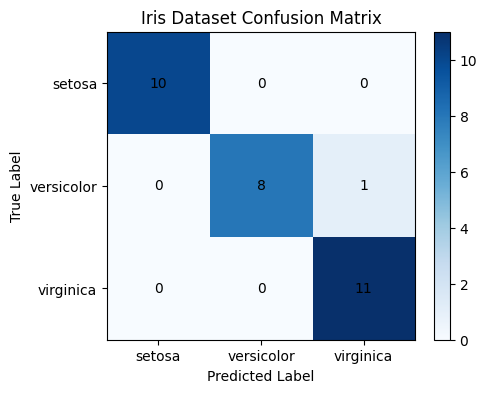


Wine Dataset
Accuracy: 1.0

Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



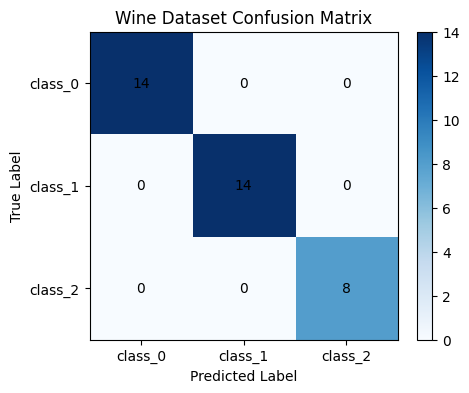

In [ ]:

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_dataset(dataset, dataset_name):

    X = dataset.data
    y = dataset.target

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Feature Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Create MLP
    model = MLPClassifier(
        hidden_layer_sizes=(10,10),
        activation='relu',
        solver='adam',
        max_iter=1000,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    print("\n" + "="*60)
    print(dataset_name)
    print("="*60)

    print("Accuracy:", accuracy_score(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=dataset.target_names
    ))

    # Plot Confusion Matrix
    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(dataset_name + " Confusion Matrix")
    plt.colorbar()

    plt.xticks(range(len(dataset.target_names)), dataset.target_names)
    plt.yticks(range(len(dataset.target_names)), dataset.target_names)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]),
                     ha="center",
                     va="center",
                     color="black")

    plt.show()

# Iris Dataset

iris = load_iris()
evaluate_dataset(iris, "Iris Dataset")

# Wine Dataset

wine = load_wine()
evaluate_dataset(wine, "Wine Dataset")